### Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

### Load Dataset

In [31]:
# Memanggil atau membaca dataset
df = pd.read_csv('../data/titanic_data.csv')

# Menampilkan 5 baris teratas dataset
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Eksplorasi Data

In [4]:
# Mengecek missing value
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Data Cleaning

In [32]:
# Menghapus kolom yang tidak diperlukan
df = df.drop(columns=['Cabin', 'Name', 'Ticket'], axis=1)
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


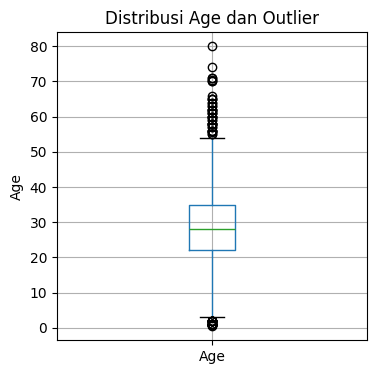

In [48]:
# Visualisasi distribusi kelas dan outlier pada kolom age
plt.figure(figsize=(4,4))
df.boxplot(column='Age')
plt.title('Distribusi Age dan Outlier')
plt.ylabel('Age')
plt.show()

In [34]:
# Komputasi nilai pada kolom Age dengan Median
df['Age'].fillna(df['Age'].median(), inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13884\2531964308.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [35]:
# Komputasi nilai modus pada kolom Embarked
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13884\3264965777.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [36]:
# Verifikasi kembali missing value
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

### Encoding Data

In [39]:
replacements = {
    'Sex': {'male': 0, 'female': 1},
    'Embarked': {'S':0, 'C':1, 'Q':2}
}

df.replace(replacements, inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13884\75453252.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(replacements, inplace=True)


In [40]:
# Melihat 5 baris teratas dataset setelah encoding
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,0,22.0,1,0,7.2500,0
1,2,1,1,1,38.0,1,0,71.2833,1
2,3,1,3,1,26.0,0,0,7.9250,0
3,4,1,1,1,35.0,1,0,53.1000,0
4,5,0,3,0,35.0,0,0,8.0500,0


### Split data dan Transformasi (Scaling)

##### Split Data Variabel X dan Y

In [49]:
# Variabel X
X = df.drop(columns=['Survived'], axis=1)

# Variabel y
y = df['Survived']

##### Transform Data

In [50]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

##### Train_Test_Split

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, 
    y, 
    test_size=0.2, 
    random_state=42
)

### Modeling

In [56]:
X_train.shape

(712, 8)

In [57]:
X_train.shape[1]

8

### Pembuatan Modeling ANN

In [59]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

# Hidden Layer 1
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))

# Dropout untuk mengurangi overfitting
model.add(Dropout(0.3))

# Hidden Layer 2
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.3))

# Output Layer (binary classification)
model.add(Dense(1, activation='sigmoid'))

c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [60]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

### Early Stopping (Pencegahan Overfitting Selama Training)

In [63]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5,
    restore_best_weights=True
)

### Training Model Neural Network

In [64]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.4640 - loss: 0.7931 - val_accuracy: 0.5734 - val_loss: 0.6820
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5677 - loss: 0.6992 - val_accuracy: 0.7273 - val_loss: 0.6438
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6221 - loss: 0.6678 - val_accuracy: 0.7203 - val_loss: 0.6246
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6520 - loss: 0.6536 - val_accuracy: 0.7203 - val_loss: 0.6077
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6854 - loss: 0.6299 - val_accuracy: 0.7273 - val_loss: 0.5962
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6960 - loss: 0.6071 - val_accuracy: 0.7343 - val_loss: 0.5767
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7206 - loss: 0.5966 - val_accuracy: 0.7483 - val_loss: 0.5608
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7170 - loss: 0.5942 - val_accuracy: 0.7483 - 

### Evaluasi Model (Testing Data)

In [65]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8268 - loss: 0.4172
Test Loss: 0.4171581566333771
Test Accuracy: 0.826815664768219


### Visualisasi Hasil Pelatihan (Accuracy dan Loss)

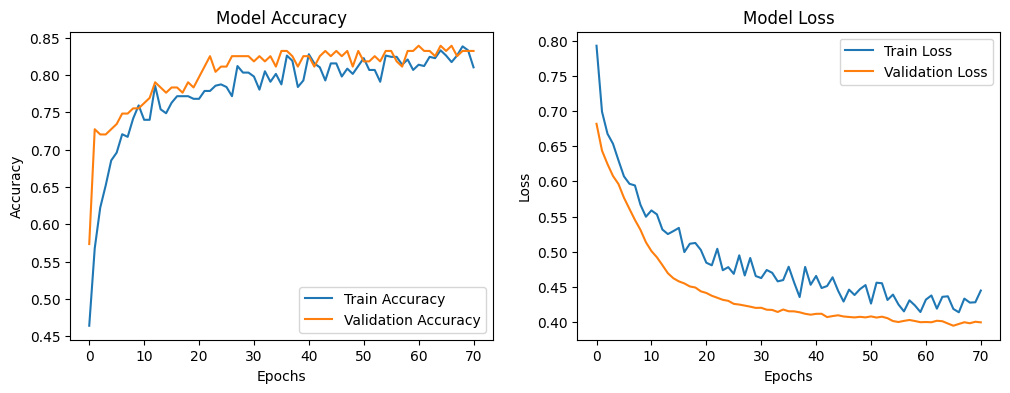

In [66]:
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Menampilkan plot
plt.show()

### Kesimpulan

Berdasarkan hasil praktikum Machine Learning – Neural Network (Artificial Neural Network) yang telah
dilakukan menggunakan dataset Titanic, dapat disimpulkan beberapa hal penting sebagai berikut:
1. Model Artificial Neural Network (ANN) berhasil dibangun menggunakan arsitektur berurutan
(Sequential Model) dengan dua hidden layer berukuran 32 dan 16 neuron serta fungsi aktivasi
ReLU, dan satu output layer dengan fungsi aktivasi Sigmoid untuk klasifikasi biner.
2. Model dikompilasi dengan optimizer Adam dan loss function Binary Crossentropy, serta
dievaluasi menggunakan akurasi (accuracy) sebagai metrik utama.
3. Untuk mencegah overfitting, digunakan teknik EarlyStopping dengan parameter
monitor='val_loss', patience=5, dan restore_best_weights=True, sehingga proses training
berhenti otomatis ketika performa model tidak membaik lagi.
4. Berdasarkan hasil evaluasi:
o Nilai Test Accuracy ≈ 0.80 (80%), menunjukkan model mampu memprediksi status
keselamatan penumpang dengan cukup baik.
o Nilai Test Loss ≈ 0.39, menunjukkan tingkat kesalahan prediksi yang rendah.
o Grafik accuracy dan loss menunjukkan tren stabil tanpa tanda overfitting, dengan
validation accuracy mendekati training accuracy.